# vOTU quality robustness

This notebook tests whether the conclusions from the fixed 1.5x rank-abundance-selected vOTU set depend on fragmented viral genomes.

The 1.5x candidate set is read from 11 and is not recalculated here. CheckV restrictions are applied afterward, so this is a genome-quality sensitivity analysis rather than a different selection rule.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.stats import mannwhitneyu, rankdata, spearmanr, wilcoxon
from IPython.display import SVG, display

VIRAL_FRACTION_DIR = Path("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION")
FIGURES_TABLES_DIR = VIRAL_FRACTION_DIR / "FIGURES_AND_TABLES"
VIRAL_MAPPING_REFERENCES_DIR = VIRAL_FRACTION_DIR / "06_MAPPING" / "REFERENCES"
VOTU_METADATA_PATH = VIRAL_FRACTION_DIR / "vOTU_metadata.csv"

THRESHOLD_SELECTION_OUTPUT_DIR = (
    FIGURES_TABLES_DIR
    / "SUPPLEMENTARY"
    / "11_rank_abundance_threshold_selection"
)
FULL_THRESHOLD_MEMBERSHIP_PATH = (
    THRESHOLD_SELECTION_OUTPUT_DIR / "11_full_phyllosphere_threshold_membership.csv"
)
RPKM_PATH = (
    VIRAL_MAPPING_REFERENCES_DIR
    / "filtered_active_vOTUs_threshold_1p5_RPKM_normalised_tot.txt"
)

BACTERIAL_JACCARD_PATH = FIGURES_TABLES_DIR / "bacterial_jaccard_matrix.csv"
BACTERIAL_HELLINGER_PATH = FIGURES_TABLES_DIR / "bacterial_hellinger_matrix.csv"
VIRAL_JACCARD_PATH = FIGURES_TABLES_DIR / "viral_jaccard_matrix.csv"
VIRAL_HELLINGER_PATH = FIGURES_TABLES_DIR / "viral_hellinger_matrix.csv"

OUTPUT_DIR = (
    FIGURES_TABLES_DIR
    / "SUPPLEMENTARY"
    / "15_vOTU_quality_robustness"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLES = [
    "vFL", "vOL", "vF23",
    "vN1", "vN2", "vN3",
    "vZ1", "vZ2", "vZ3",
    "vF1A", "vF2A", "vF3A",
    "vF1B", "vF2B", "vF3B",
    "vF1C", "vF2C", "vF3C",
    "vO1A", "vO2A", "vO3A",
    "vO1B", "vO2B", "vO3B",
    "vO1C", "vO2C", "vO3C",
    "vS1B", "vS2B", "vS3B",
    "vS1C", "vS2C", "vS3C",
    "vNWd", "vSWd", "vSEd",
]
SAMPLES_DK = SAMPLES[:33]

DEFAULT_THRESHOLD_KEY = "1.5"
LIFESTYLE_ORDER = ["Temperate", "Virulent"]
QUALITY_SETS = [
    {
        "quality_set": "All vOTUs",
        "included_checkv_quality": "All CheckV calls",
        "allowed_checkv_quality": None,
    },
    {
        "quality_set": "Medium-quality or better",
        "included_checkv_quality": "Medium-quality, High-quality, Complete",
        "allowed_checkv_quality": {
            "Medium-quality",
            "High-quality",
            "Complete",
        },
    },
    {
        "quality_set": "High-quality or Complete",
        "included_checkv_quality": "High-quality, Complete",
        "allowed_checkv_quality": {"High-quality", "Complete"},
    },
]
QUALITY_SET_ORDER = [entry["quality_set"] for entry in QUALITY_SETS]
QUALITY_SET_COLORS = {
    "All vOTUs": "#3399CC",
    "Medium-quality or better": "#33CC99",
    "High-quality or Complete": "#FFCC00",
}

PREVALENCE_GROUP_ORDER = [
    "Not detected in Danish samples",
    "Low overlap/unique",
    "Common",
    "Core",
    "Ubiquitous",
]
PLOT_PREVALENCE_GROUPS = [
    "Ubiquitous",
    "Core",
    "Common",
    "Low overlap/unique",
]
QUALITY_CLASS_ORDER = [
    "Low-quality",
    "Medium-quality",
    "High-quality/Complete",
    "Other CheckV",
]
QUALITY_CLASS_COLORS = {
    "Low-quality": "#666666",
    "Medium-quality": "#78AEDD",
    "High-quality/Complete": "#33CC99",
    "Other CheckV": "#D9D9D9",
}
COMMUNITY_METRICS = [
    ("Jaccard", "Jaccard", "#3399CC"),
    ("Hellinger", "Hellinger", "#E6865B"),
]

N_MANTEL_PERMUTATIONS = 9_999
RANDOM_SEED = 20260730

sns.set_style("ticks", {"axes.grid": True})


def format_p_value(p_value):
    if pd.isna(p_value):
        return "NA"
    if p_value < 0.001:
        return "<0.001"
    return f"{p_value:.3f}"


## Fixed 1.5x vOTUs and CheckV sets


In [2]:
required_paths = [
    FULL_THRESHOLD_MEMBERSHIP_PATH,
    RPKM_PATH,
    BACTERIAL_JACCARD_PATH,
    BACTERIAL_HELLINGER_PATH,
    VIRAL_JACCARD_PATH,
    VIRAL_HELLINGER_PATH,
]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Required 15 inputs are missing: "
        f"{[str(path) for path in missing_paths]}"
    )

threshold_membership = pd.read_csv(
    FULL_THRESHOLD_MEMBERSHIP_PATH,
    dtype={"threshold_multiplier": str, "vOTU": str},
)
required_membership_columns = {
    "threshold_multiplier",
    "vOTU",
    "rank_abundance_call",
}
missing_membership_columns = sorted(
    required_membership_columns.difference(threshold_membership.columns)
)
if missing_membership_columns:
    raise ValueError(
        "11 membership table is missing columns: "
        f"{missing_membership_columns}"
    )

selected_votu_ids = set(
    threshold_membership.loc[
        threshold_membership["threshold_multiplier"].eq(DEFAULT_THRESHOLD_KEY)
        & threshold_membership["rank_abundance_call"].eq("retained"),
        "vOTU",
    ]
)
if not selected_votu_ids:
    raise ValueError("11 did not contain any retained 1.5x vOTUs.")

votu_metadata = pd.read_csv(VOTU_METADATA_PATH, low_memory=False)
votu_metadata["vOTU"] = votu_metadata["vOTU"].astype(str)
required_metadata_columns = {
    "vOTU",
    "checkv_quality",
    "BACPLHIP_lifestyle",
}
missing_metadata_columns = sorted(
    required_metadata_columns.difference(votu_metadata.columns)
)
if missing_metadata_columns:
    raise ValueError(
        "vOTU metadata are missing columns: "
        f"{missing_metadata_columns}"
    )

metadata_columns = [
    "vOTU",
    "checkv_quality",
    "BACPLHIP_lifestyle",
]
if "Host genus" in votu_metadata.columns:
    metadata_columns.append("Host genus")

metadata_subset = votu_metadata.loc[
    votu_metadata["vOTU"].isin(selected_votu_ids),
    metadata_columns,
].copy()
if "Host genus" not in metadata_subset.columns:
    metadata_subset["Host genus"] = np.nan
if metadata_subset["vOTU"].duplicated().any():
    duplicate_ids = (
        metadata_subset.loc[
            metadata_subset["vOTU"].duplicated(),
            "vOTU",
        ]
        .head()
        .tolist()
    )
    raise ValueError(f"vOTU metadata contain duplicate IDs: {duplicate_ids}")

missing_metadata_ids = selected_votu_ids.difference(metadata_subset["vOTU"])
if missing_metadata_ids:
    raise ValueError(
        "vOTU metadata are missing 1.5x-selected IDs: "
        f"{sorted(missing_metadata_ids)[:5]}"
    )

rpkm = pd.read_csv(RPKM_PATH, low_memory=False)
rpkm["vOTU"] = rpkm["vOTU"].astype(str)
if rpkm["vOTU"].duplicated().any():
    duplicate_ids = rpkm.loc[rpkm["vOTU"].duplicated(), "vOTU"].head().tolist()
    raise ValueError(f"The 1.5x RPKM table contains duplicate IDs: {duplicate_ids}")

missing_samples = sorted(set(SAMPLES).difference(rpkm.columns))
if missing_samples:
    raise ValueError(
        "The 1.5x RPKM table is missing sample columns: "
        f"{missing_samples}"
    )

missing_rpkm_ids = selected_votu_ids.difference(rpkm["vOTU"])
if missing_rpkm_ids:
    raise ValueError(
        "The 1.5x RPKM table is missing selected vOTUs: "
        f"{sorted(missing_rpkm_ids)[:5]}"
    )

selected_votus = metadata_subset.merge(
    rpkm.loc[rpkm["vOTU"].isin(selected_votu_ids), ["vOTU"] + SAMPLES],
    on="vOTU",
    how="left",
    validate="one_to_one",
)
selected_votus[SAMPLES] = (
    selected_votus[SAMPLES]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
)

quality_sets = {}
quality_membership_rows = []
quality_summary_rows = []
all_selected_rpkm = selected_votus[SAMPLES].to_numpy().sum()

for definition in QUALITY_SETS:
    quality_set = definition["quality_set"]
    allowed_checkv_quality = definition["allowed_checkv_quality"]

    if allowed_checkv_quality is None:
        subset = selected_votus.copy()
    else:
        subset = selected_votus.loc[
            selected_votus["checkv_quality"].isin(allowed_checkv_quality)
        ].copy()

    if subset.empty:
        raise ValueError(f"{quality_set} contains no 1.5x-selected vOTUs.")

    quality_sets[quality_set] = subset
    quality_membership_rows.extend(
        {
            "quality_set": quality_set,
            "vOTU": row.vOTU,
            "checkv_quality": row.checkv_quality,
            "BACPLHIP_lifestyle": row.BACPLHIP_lifestyle,
        }
        for row in subset.itertuples(index=False)
    )

    lifestyle_called = subset["BACPLHIP_lifestyle"].isin(LIFESTYLE_ORDER)
    quality_summary_rows.append(
        {
            "quality_set": quality_set,
            "CheckV calls included": definition["included_checkv_quality"],
            "vOTUs": len(subset),
            "Temperate": int(subset["BACPLHIP_lifestyle"].eq("Temperate").sum()),
            "Virulent": int(subset["BACPLHIP_lifestyle"].eq("Virulent").sum()),
            "No lifestyle call": int((~lifestyle_called).sum()),
            "RPKM retained (%)": (
                100 * subset[SAMPLES].to_numpy().sum() / all_selected_rpkm
                if all_selected_rpkm > 0
                else np.nan
            ),
        }
    )

quality_set_summary = pd.DataFrame(quality_summary_rows)
quality_membership = pd.DataFrame(quality_membership_rows)

quality_set_summary.to_csv(
    OUTPUT_DIR / "15_quality_set_summary.csv",
    index=False,
)
quality_membership.to_csv(
    OUTPUT_DIR / "15_vOTU_quality_membership.csv",
    index=False,
)

quality_set_summary_display = quality_set_summary.copy()
quality_set_summary_display["RPKM retained (%)"] = (
    quality_set_summary_display["RPKM retained (%)"].round(1)
)
display(quality_set_summary_display)


,quality_set,CheckV calls included,vOTUs,Temperate,Virulent,No lifestyle call,RPKM retained (%)
0,All vOTUs,All CheckV calls,726,294,432,0,100.0
1,Medium-quality or better,"Medium-quality, High-quality, Complete",485,234,251,0,83.0
2,High-quality or Complete,"High-quality, Complete",317,155,162,0,66.7


## Danish prevalence classes and core retention

Prevalence classes are calculated from the 33 Danish samples exactly as in the manuscript: low overlap/unique is below 20%, common is at least 20%, core is at least 50%, and ubiquitous is 100%. Quality filtering does not reclassify a vOTU; it shows how many of the original prevalence classes remain.


In [3]:
def prevalence_group(detected_samples):
    prevalence = detected_samples / len(SAMPLES_DK)
    if detected_samples == 0:
        return "Not detected in Danish samples"
    if prevalence < 0.20:
        return "Low overlap/unique"
    if prevalence < 0.50:
        return "Common"
    if prevalence < 1.00:
        return "Core"
    return "Ubiquitous"


def quality_class(checkv_quality):
    if checkv_quality == "Low-quality":
        return "Low-quality"
    if checkv_quality == "Medium-quality":
        return "Medium-quality"
    if checkv_quality in {"High-quality", "Complete"}:
        return "High-quality/Complete"
    return "Other CheckV"


prevalence_by_votu = selected_votus[
    ["vOTU", "checkv_quality", "BACPLHIP_lifestyle", "Host genus"] + SAMPLES_DK
].copy()
prevalence_by_votu["detected_Danish_samples"] = (
    prevalence_by_votu[SAMPLES_DK].gt(0).sum(axis=1)
)
prevalence_by_votu["Danish_prevalence_percent"] = (
    100 * prevalence_by_votu["detected_Danish_samples"] / len(SAMPLES_DK)
)
prevalence_by_votu["prevalence_group"] = prevalence_by_votu[
    "detected_Danish_samples"
].map(prevalence_group)
prevalence_by_votu["quality_class"] = prevalence_by_votu["checkv_quality"].map(
    quality_class
)
prevalence_by_votu["mean_Danish_RPKM"] = prevalence_by_votu[SAMPLES_DK].mean(axis=1)
prevalence_by_votu["retained_medium_quality_or_better"] = (
    prevalence_by_votu["checkv_quality"].isin(
        {"Medium-quality", "High-quality", "Complete"}
    )
)
prevalence_by_votu["retained_high_quality_or_complete"] = (
    prevalence_by_votu["checkv_quality"].isin({"High-quality", "Complete"})
)

prevalence_summary_rows = []
for group in PREVALENCE_GROUP_ORDER:
    group_df = prevalence_by_votu.loc[
        prevalence_by_votu["prevalence_group"].eq(group)
    ]
    n_all = len(group_df)
    n_medium = int(group_df["retained_medium_quality_or_better"].sum())
    n_strict = int(group_df["retained_high_quality_or_complete"].sum())
    strict_df = group_df.loc[group_df["retained_high_quality_or_complete"]]

    prevalence_summary_rows.append(
        {
            "prevalence_group": group,
            "all_vOTUs": n_all,
            "medium_quality_or_better": n_medium,
            "high_quality_or_complete": n_strict,
            "medium_quality_or_better_retained (%)": (
                100 * n_medium / n_all if n_all else np.nan
            ),
            "high_quality_or_complete_retained (%)": (
                100 * n_strict / n_all if n_all else np.nan
            ),
            "Temperate_all": int(
                group_df["BACPLHIP_lifestyle"].eq("Temperate").sum()
            ),
            "Virulent_all": int(
                group_df["BACPLHIP_lifestyle"].eq("Virulent").sum()
            ),
            "Temperate_high_quality_or_complete": int(
                strict_df["BACPLHIP_lifestyle"].eq("Temperate").sum()
            ),
            "Virulent_high_quality_or_complete": int(
                strict_df["BACPLHIP_lifestyle"].eq("Virulent").sum()
            ),
        }
    )

prevalence_quality_summary = pd.DataFrame(prevalence_summary_rows)
ubiquitous_votus = (
    prevalence_by_votu.loc[
        prevalence_by_votu["prevalence_group"].eq("Ubiquitous"),
        [
            "vOTU",
            "checkv_quality",
            "BACPLHIP_lifestyle",
            "Host genus",
            "mean_Danish_RPKM",
            "retained_medium_quality_or_better",
            "retained_high_quality_or_complete",
        ],
    ]
    .rename(columns={"Host genus": "predicted_host_genus"})
    .sort_values("mean_Danish_RPKM", ascending=False)
    .reset_index(drop=True)
)

prevalence_by_votu.to_csv(
    OUTPUT_DIR / "15_Danish_prevalence_by_vOTU.csv",
    index=False,
)
prevalence_quality_summary.to_csv(
    OUTPUT_DIR / "15_Danish_prevalence_quality_summary.csv",
    index=False,
)
ubiquitous_votus.to_csv(
    OUTPUT_DIR / "15_ubiquitous_vOTUs_quality_table.csv",
    index=False,
)

prevalence_quality_summary_display = prevalence_quality_summary.copy()
for column in [
    "medium_quality_or_better_retained (%)",
    "high_quality_or_complete_retained (%)",
]:
    prevalence_quality_summary_display[column] = (
        prevalence_quality_summary_display[column].round(1)
    )
display(prevalence_quality_summary_display)

ubiquitous_votus_display = ubiquitous_votus.copy()
ubiquitous_votus_display["mean_Danish_RPKM"] = (
    ubiquitous_votus_display["mean_Danish_RPKM"].round(1)
)
display(ubiquitous_votus_display)


,prevalence_group,all_vOTUs,medium_quality_or_better,high_quality_or_complete,medium_quality_or_better_retained (%),high_quality_or_complete_retained (%),Temperate_all,Virulent_all,Temperate_high_quality_or_complete,Virulent_high_quality_or_complete
0,Not detected in Danish samples,2,2,2,100.0,100.0,2,0,2,0
1,Low overlap/unique,188,106,68,56.4,36.2,48,140,17,51
2,Common,246,168,102,68.3,41.5,80,166,32,70
3,Core,277,198,135,71.5,48.7,153,124,95,40
4,Ubiquitous,13,11,10,84.6,76.9,11,2,9,1


,vOTU,checkv_quality,BACPLHIP_lifestyle,predicted_host_genus,mean_Danish_RPKM,retained_medium_quality_or_better,retained_high_quality_or_complete
0,E_aphidicola_Z9_3_pp3_cluster_15,High-quality,Temperate,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,2384.2,True,True
1,APSE_wheat,High-quality,Temperate,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,2181.1,True,True
2,vS1B_20_NODE_11_length_139468_cov_83.775100,Complete,Virulent,NaN,857.9,True,True
3,vS3C_T_NODE_78_length_14889_cov_89.463665,Low-quality,Temperate,NaN,652.0,False,False
4,vN2_10_NODE_2_length_39732_cov_172.456511,Complete,Temperate,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,575.0,True,True
5,E_aphidicola_B01_10_pp1_cluster_1,High-quality,Temperate,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,500.3,True,True
6,vO3A_70_NODE_154_length_13639_cov_186.811985,Low-quality,Temperate,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,403.4,False,False
7,E_aphidicola_Z9_3_pp1_cluster_4,High-quality,Temperate,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,364.9,True,True
8,E_aphidicola_B01_5_pp1_cluster_3,High-quality,Temperate,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,246.2,True,True
9,vO2C_NODE_54_length_77920_cov_109.386798,Medium-quality,Virulent,NaN,86.9,True,False


## Genome quality across Danish prevalence classes

This plot shows the CheckV composition of the original 1.5x-selected prevalence classes. It makes the retention of core and ubiquitous vOTUs visible without changing their prevalence definition.


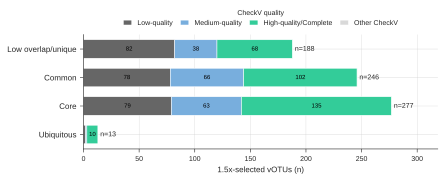

In [4]:
prevalence_quality_figure_path = (
    OUTPUT_DIR / "15_Danish_prevalence_quality_composition.svg"
)

quality_composition = (
    prevalence_by_votu.loc[
        prevalence_by_votu["prevalence_group"].isin(PLOT_PREVALENCE_GROUPS)
    ]
    .groupby(["prevalence_group", "quality_class"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=PLOT_PREVALENCE_GROUPS,
        columns=QUALITY_CLASS_ORDER,
        fill_value=0,
    )
)

with sns.axes_style("ticks", {"axes.grid": True}), plt.rc_context(
    {
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "grid.linewidth": 0.3,
        "font.family": "sans-serif",
        "font.sans-serif": ["Liberation Sans"],
        "font.size": 7,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 8,
        "legend.fontsize": 7,
        "svg.fonttype": "none",
    }
):
    fig, axis = plt.subplots(figsize=(6.2, 2.65))
    left = np.zeros(len(quality_composition))

    for quality_group in QUALITY_CLASS_ORDER:
        values = quality_composition[quality_group].to_numpy()
        bars = axis.barh(
            quality_composition.index,
            values,
            left=left,
            color=QUALITY_CLASS_COLORS[quality_group],
            edgecolor="white",
            linewidth=0.5,
            height=0.65,
            label=quality_group,
        )
        for bar, value, start in zip(bars, values, left):
            if value >= 4:
                axis.text(
                    start + value / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{int(value)}",
                    ha="center",
                    va="center",
                    fontsize=6,
                    color="black",
                )
        left += values

    for y_position, total in enumerate(quality_composition.sum(axis=1)):
        axis.text(
            total + max(1.5, quality_composition.to_numpy().max() * 0.015),
            y_position,
            f"n={int(total)}",
            va="center",
            fontsize=7,
        )

    axis.set_xlabel("1.5x-selected vOTUs (n)")
    axis.set_ylabel("")
    axis.spines[["top", "right"]].set_visible(False)
    axis.legend(
        title="CheckV quality",
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.27),
        ncol=4,
        columnspacing=1.1,
        handlelength=1.2,
    )
    axis.set_xlim(0, quality_composition.sum(axis=1).max() * 1.15)
    fig.tight_layout()
    fig.savefig(
        prevalence_quality_figure_path,
        format="svg",
        bbox_inches="tight",
    )

display(SVG(filename=str(prevalence_quality_figure_path)))
plt.close(fig)


## Lifestyle results across the quality sets

This is the compact quality sensitivity table for the main lifestyle comparisons. Relative abundance and detected-vOTU proportions use all 36 samples. Prevalence uses the 33 Danish samples, matching the core and ubiquitous analysis.


In [5]:
lifestyle_summary_rows = []

for quality_set in QUALITY_SET_ORDER:
    subset = quality_sets[quality_set]
    temperate_mask = subset["BACPLHIP_lifestyle"].eq("Temperate")
    virulent_mask = subset["BACPLHIP_lifestyle"].eq("Virulent")

    relative_rows = []
    detected_rows = []
    for sample in SAMPLES:
        total_rpkm = subset[sample].sum()
        detected = subset[sample].gt(0)
        total_detected = int(detected.sum())

        relative_rows.append(
            {
                "Temperate": (
                    100 * subset.loc[temperate_mask, sample].sum() / total_rpkm
                    if total_rpkm > 0
                    else np.nan
                ),
                "Virulent": (
                    100 * subset.loc[virulent_mask, sample].sum() / total_rpkm
                    if total_rpkm > 0
                    else np.nan
                ),
            }
        )
        detected_rows.append(
            {
                "Temperate": (
                    100 * (temperate_mask & detected).sum() / total_detected
                    if total_detected > 0
                    else np.nan
                ),
                "Virulent": (
                    100 * (virulent_mask & detected).sum() / total_detected
                    if total_detected > 0
                    else np.nan
                ),
            }
        )

    relative_abundance = pd.DataFrame(relative_rows).dropna()
    detected_proportion = pd.DataFrame(detected_rows).dropna()
    try:
        _, relative_p_value = wilcoxon(
            relative_abundance["Temperate"],
            relative_abundance["Virulent"],
        )
    except ValueError:
        relative_p_value = np.nan
    try:
        _, detected_p_value = wilcoxon(
            detected_proportion["Temperate"],
            detected_proportion["Virulent"],
        )
    except ValueError:
        detected_p_value = np.nan

    prevalence = 100 * subset[SAMPLES_DK].gt(0).sum(axis=1) / len(SAMPLES_DK)
    temperate_prevalence = prevalence.loc[temperate_mask]
    virulent_prevalence = prevalence.loc[virulent_mask]
    try:
        _, prevalence_p_value = mannwhitneyu(
            temperate_prevalence,
            virulent_prevalence,
            alternative="two-sided",
        )
    except ValueError:
        prevalence_p_value = np.nan

    quality_row = quality_set_summary.loc[
        quality_set_summary["quality_set"].eq(quality_set)
    ].iloc[0]
    lifestyle_summary_rows.append(
        {
            "quality_set": quality_set,
            "vOTUs": int(quality_row["vOTUs"]),
            "RPKM retained (%)": quality_row["RPKM retained (%)"],
            "Temperate": int(temperate_mask.sum()),
            "Virulent": int(virulent_mask.sum()),
            "Temperate mean relative abundance (%)": relative_abundance[
                "Temperate"
            ].mean(),
            "Virulent mean relative abundance (%)": relative_abundance[
                "Virulent"
            ].mean(),
            "Relative abundance P (Wilcoxon)": relative_p_value,
            "Temperate mean prevalence (%)": temperate_prevalence.mean(),
            "Virulent mean prevalence (%)": virulent_prevalence.mean(),
            "Prevalence P (Mann-Whitney U)": prevalence_p_value,
            "Temperate mean detected vOTUs (%)": detected_proportion[
                "Temperate"
            ].mean(),
            "Virulent mean detected vOTUs (%)": detected_proportion[
                "Virulent"
            ].mean(),
            "Detected vOTUs P (Wilcoxon)": detected_p_value,
        }
    )

lifestyle_quality_summary = pd.DataFrame(lifestyle_summary_rows)
lifestyle_quality_summary.to_csv(
    OUTPUT_DIR / "15_lifestyle_quality_summary.csv",
    index=False,
)

lifestyle_quality_display = lifestyle_quality_summary.copy()
for column in lifestyle_quality_display.columns:
    if "mean" in column or column == "RPKM retained (%)":
        lifestyle_quality_display[column] = lifestyle_quality_display[column].round(1)
    if " P (" in column:
        lifestyle_quality_display[column] = (
            lifestyle_quality_display[column].map(format_p_value)
        )
display(lifestyle_quality_display)


,quality_set,vOTUs,RPKM retained (%),Temperate,Virulent,Temperate mean relative abundance (%),Virulent mean relative abundance (%),Relative abundance P (Wilcoxon),Temperate mean prevalence (%),Virulent mean prevalence (%),Prevalence P (Mann-Whitney U),Temperate mean detected vOTUs (%),Virulent mean detected vOTUs (%),Detected vOTUs P (Wilcoxon)
0,All vOTUs,726,100.0,294,432,58.6,41.4,0.026,50.9,34.9,<0.001,54.4,45.6,0.007
1,Medium-quality or better,485,83.0,234,251,59.5,40.5,0.017,52.7,35.6,<0.001,61.9,38.1,<0.001
2,High-quality or Complete,317,66.7,155,162,63.3,36.7,0.006,56.7,33.9,<0.001,67.0,33.0,<0.001


## Bacterial-viral community concordance

The bacterial distance matrices are the same matrices used in the manuscript. Viral Jaccard and Hellinger distances are recalculated for every quality set across the same 35 matched samples. The all-vOTU reconstruction is checked against the saved manuscript matrices before the restricted sets are compared.


In [6]:
def read_distance_matrix(path):
    matrix = pd.read_csv(path, index_col=0)
    matrix.index = matrix.index.astype(str)
    matrix.columns = matrix.columns.astype(str)

    if set(matrix.index) != set(matrix.columns):
        raise ValueError(f"Distance matrix index and columns differ: {path}")
    matrix = matrix.loc[matrix.index, matrix.index]

    if not np.allclose(matrix.to_numpy(), matrix.to_numpy().T, atol=1e-10):
        raise ValueError(f"Distance matrix is not symmetric: {path}")
    if not np.allclose(np.diag(matrix.to_numpy()), 0, atol=1e-10):
        raise ValueError(f"Distance matrix diagonal is not zero: {path}")
    return matrix


def viral_distance_matrix(subset, virome_samples, sample_labels, metric):
    counts = (
        subset.set_index("vOTU")
        .loc[:, virome_samples]
        .T
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
    )

    if metric == "Jaccard":
        distances = squareform(
            pdist(counts.gt(0).to_numpy(dtype=bool), metric="jaccard")
        )
    elif metric == "Hellinger":
        relative = counts.div(
            counts.sum(axis=1).replace(0, np.nan),
            axis=0,
        ).fillna(0.0)
        distances = (
            squareform(pdist(np.sqrt(relative).to_numpy(), metric="euclidean"))
            / np.sqrt(2)
        )
    else:
        raise ValueError(f"Unsupported community metric: {metric}")

    return pd.DataFrame(
        distances,
        index=sample_labels,
        columns=sample_labels,
    )


def mantel_spearman(left, right, rng):
    left = np.asarray(left, dtype=float)
    right = np.asarray(right, dtype=float)
    if left.shape != right.shape or left.shape[0] != left.shape[1]:
        raise ValueError("Mantel matrices must be square and have the same shape.")

    n_samples = left.shape[0]
    upper = np.triu_indices(n_samples, k=1)
    left_ranks = rankdata(left[upper])
    right_ranks = rankdata(right[upper])

    left_centered = left_ranks - left_ranks.mean()
    left_norm = np.linalg.norm(left_centered)
    right_centered = right_ranks - right_ranks.mean()
    right_norm = np.linalg.norm(right_centered)
    if left_norm == 0 or right_norm == 0:
        return np.nan, np.nan

    observed_rho = np.dot(left_centered, right_centered) / (left_norm * right_norm)

    rank_matrix = np.zeros_like(right, dtype=float)
    rank_matrix[upper] = right_ranks
    rank_matrix[(upper[1], upper[0])] = right_ranks

    n_as_extreme = 0
    for _ in range(N_MANTEL_PERMUTATIONS):
        permutation = rng.permutation(n_samples)
        permuted_ranks = rank_matrix[np.ix_(permutation, permutation)][upper]
        permuted_centered = permuted_ranks - permuted_ranks.mean()
        permuted_norm = np.linalg.norm(permuted_centered)
        if permuted_norm == 0:
            continue
        permuted_rho = (
            np.dot(left_centered, permuted_centered)
            / (left_norm * permuted_norm)
        )
        if abs(permuted_rho) >= abs(observed_rho):
            n_as_extreme += 1

    p_value = (n_as_extreme + 1) / (N_MANTEL_PERMUTATIONS + 1)
    return observed_rho, p_value


bacterial_jaccard = read_distance_matrix(BACTERIAL_JACCARD_PATH)
bacterial_hellinger = read_distance_matrix(BACTERIAL_HELLINGER_PATH)
viral_jaccard_reference = read_distance_matrix(VIRAL_JACCARD_PATH)
viral_hellinger_reference = read_distance_matrix(VIRAL_HELLINGER_PATH)

matched_sample_labels = bacterial_jaccard.index.tolist()
if set(bacterial_hellinger.index) != set(matched_sample_labels):
    raise ValueError("The bacterial Jaccard and Hellinger matrices use different samples.")
if set(viral_jaccard_reference.index) != set(matched_sample_labels):
    raise ValueError("The bacterial and viral Jaccard matrices use different samples.")
if set(viral_hellinger_reference.index) != set(matched_sample_labels):
    raise ValueError("The bacterial and viral Hellinger matrices use different samples.")

bacterial_hellinger = bacterial_hellinger.loc[
    matched_sample_labels,
    matched_sample_labels,
]
viral_jaccard_reference = viral_jaccard_reference.loc[
    matched_sample_labels,
    matched_sample_labels,
]
viral_hellinger_reference = viral_hellinger_reference.loc[
    matched_sample_labels,
    matched_sample_labels,
]

matched_virome_samples = [f"v{sample}" for sample in matched_sample_labels]
missing_matched_virome_samples = sorted(
    set(matched_virome_samples).difference(selected_votus.columns)
)
if missing_matched_virome_samples:
    raise ValueError(
        "The 1.5x RPKM table is missing paired virome samples: "
        f"{missing_matched_virome_samples}"
    )

viral_distance_matrices = {}
for quality_set in QUALITY_SET_ORDER:
    subset = quality_sets[quality_set]
    viral_distance_matrices[quality_set] = {
        "Jaccard": viral_distance_matrix(
            subset,
            matched_virome_samples,
            matched_sample_labels,
            "Jaccard",
        ),
        "Hellinger": viral_distance_matrix(
            subset,
            matched_virome_samples,
            matched_sample_labels,
            "Hellinger",
        ),
    }

reference_matrices = {
    "Jaccard": viral_jaccard_reference,
    "Hellinger": viral_hellinger_reference,
}
reconstruction_rows = []
for metric, _, _ in COMMUNITY_METRICS:
    maximum_absolute_difference = np.abs(
        viral_distance_matrices["All vOTUs"][metric].to_numpy()
        - reference_matrices[metric].to_numpy()
    ).max()
    reconstruction_rows.append(
        {
            "metric": metric,
            "maximum_absolute_difference": maximum_absolute_difference,
        }
    )
    if maximum_absolute_difference > 1e-8:
        raise ValueError(
            f"The all-vOTU {metric} matrix does not reproduce the saved "
            f"manuscript matrix (maximum difference "
            f"{maximum_absolute_difference:.3g})."
        )

community_reconstruction_check = pd.DataFrame(reconstruction_rows)
community_reconstruction_check.to_csv(
    OUTPUT_DIR / "15_all_vOTU_distance_reconstruction_check.csv",
    index=False,
)
display(community_reconstruction_check)

bacterial_distance_matrices = {
    "Jaccard": bacterial_jaccard,
    "Hellinger": bacterial_hellinger,
}
upper = np.triu_indices(len(matched_sample_labels), k=1)
rng = np.random.default_rng(RANDOM_SEED)
community_summary_rows = []

for quality_set in QUALITY_SET_ORDER:
    for metric, _, _ in COMMUNITY_METRICS:
        viral_matrix = viral_distance_matrices[quality_set][metric]
        bacterial_matrix = bacterial_distance_matrices[metric]

        mantel_rho, mantel_p_value = mantel_spearman(
            bacterial_matrix.to_numpy(),
            viral_matrix.to_numpy(),
            rng,
        )
        stability_rho = spearmanr(
            viral_jaccard_reference.to_numpy()[upper]
            if metric == "Jaccard"
            else viral_hellinger_reference.to_numpy()[upper],
            viral_matrix.to_numpy()[upper],
        ).statistic

        community_summary_rows.append(
            {
                "quality_set": quality_set,
                "metric": metric,
                "matched_samples": len(matched_sample_labels),
                "bacterial_viral_mantel_rho": mantel_rho,
                "bacterial_viral_mantel_p_value": mantel_p_value,
                "viral_distance_similarity_to_all_rho": stability_rho,
            }
        )

community_concordance_summary = pd.DataFrame(community_summary_rows)
community_concordance_summary["quality_set"] = pd.Categorical(
    community_concordance_summary["quality_set"],
    categories=QUALITY_SET_ORDER,
    ordered=True,
)
community_concordance_summary.to_csv(
    OUTPUT_DIR / "15_bacterial_viral_community_concordance.csv",
    index=False,
)

community_display = community_concordance_summary.copy()
for column in [
    "bacterial_viral_mantel_rho",
    "viral_distance_similarity_to_all_rho",
]:
    community_display[column] = community_display[column].round(3)
community_display["bacterial_viral_mantel_p_value"] = (
    community_display["bacterial_viral_mantel_p_value"].map(format_p_value)
)
display(community_display)


,metric,maximum_absolute_difference
0,Jaccard,1.110223e-16
1,Hellinger,8.881784e-16


,quality_set,metric,matched_samples,bacterial_viral_mantel_rho,bacterial_viral_mantel_p_value,viral_distance_similarity_to_all_rho
0,All vOTUs,Jaccard,35,0.709,<0.001,1.000
1,All vOTUs,Hellinger,35,0.308,0.002,1.000
2,Medium-quality or better,Jaccard,35,0.717,<0.001,0.995
3,Medium-quality or better,Hellinger,35,0.260,0.007,0.989
4,High-quality or Complete,Jaccard,35,0.721,<0.001,0.990
5,High-quality or Complete,Hellinger,35,0.238,0.015,0.968


## Community concordance across genome-quality sets

The left panel asks whether bacterial and viral community structure remains associated. The right panel shows how closely each restricted viral distance matrix follows the full 1.5x viral community structure. Permutation P values are reported in the table above.


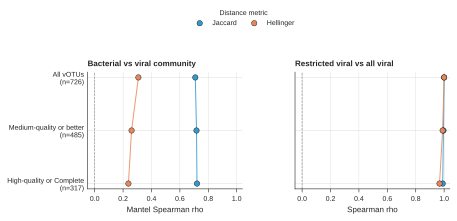

In [7]:
community_figure_path = OUTPUT_DIR / "15_community_concordance_by_quality.svg"

quality_plot_labels = {
    row["quality_set"]: f'{row["quality_set"]}\n(n={int(row["vOTUs"])})'
    for _, row in quality_set_summary.iterrows()
}
quality_y_positions = np.arange(len(QUALITY_SET_ORDER))[::-1]

with sns.axes_style("ticks", {"axes.grid": True}), plt.rc_context(
    {
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "grid.linewidth": 0.3,
        "font.family": "sans-serif",
        "font.sans-serif": ["Liberation Sans"],
        "font.size": 7,
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "axes.titleweight": "bold",
        "svg.fonttype": "none",
    }
):
    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(7.0, 2.8),
        sharey=True,
    )

    plot_columns = [
        (
            axes[0],
            "bacterial_viral_mantel_rho",
            "Bacterial vs viral community",
            "Mantel Spearman rho",
        ),
        (
            axes[1],
            "viral_distance_similarity_to_all_rho",
            "Restricted viral vs all viral",
            "Spearman rho",
        ),
    ]

    legend_handles = []
    for axis, value_column, title, xlabel in plot_columns:
        for metric, metric_label, metric_color in COMMUNITY_METRICS:
            metric_rows = (
                community_concordance_summary.loc[
                    community_concordance_summary["metric"].eq(metric)
                ]
                .set_index("quality_set")
                .reindex(QUALITY_SET_ORDER)
            )
            values = metric_rows[value_column].to_numpy()
            axis.plot(
                values,
                quality_y_positions,
                color=metric_color,
                linewidth=1.0,
                alpha=0.85,
                zorder=2,
            )
            handle = axis.scatter(
                values,
                quality_y_positions,
                color=metric_color,
                edgecolor="black",
                linewidth=0.4,
                s=30,
                zorder=3,
                label=metric_label,
            )
            if axis is axes[0]:
                legend_handles.append(handle)

        axis.axvline(0, color="#777777", linestyle="--", linewidth=0.65, zorder=0)
        axis.set_title(title, loc="left")
        axis.set_xlabel(xlabel)
        axis.set_xlim(-0.05, 1.04)
        axis.spines[["top", "right"]].set_visible(False)
        axis.tick_params(axis="y", length=0)

    axes[0].set_yticks(quality_y_positions)
    axes[0].set_yticklabels(
        [quality_plot_labels[quality_set] for quality_set in QUALITY_SET_ORDER]
    )
    axes[1].tick_params(axis="y", labelleft=False)

    fig.legend(
        legend_handles,
        [label for _, label, _ in COMMUNITY_METRICS],
        title="Distance metric",
        frameon=False,
        ncol=2,
        loc="upper center",
        bbox_to_anchor=(0.58, 1.12),
        columnspacing=1.5,
    )
    fig.subplots_adjust(left=0.27, right=0.99, bottom=0.2, top=0.78, wspace=0.34)
    fig.savefig(community_figure_path, format="svg", bbox_inches="tight")

display(SVG(filename=str(community_figure_path)))
plt.close(fig)


## Complete quality-set summary

This table brings together the vOTU counts, Danish prevalence-class counts, lifestyle statistics, and bacterial-viral community statistics for the three nested CheckV sets. Numerical P values are retained in the CSV; values shown in the notebook are rounded for reading.

In [8]:
full_summary_rows = []

for quality_set in QUALITY_SET_ORDER:
    subset = quality_sets[quality_set]
    subset_votu_ids = set(subset["vOTU"])
    prevalence_counts = (
        prevalence_by_votu.loc[
            prevalence_by_votu["vOTU"].isin(subset_votu_ids),
            "prevalence_group",
        ]
        .value_counts()
        .reindex(PREVALENCE_GROUP_ORDER, fill_value=0)
    )

    quality_row = quality_set_summary.loc[
        quality_set_summary["quality_set"].eq(quality_set)
    ].iloc[0]
    lifestyle_row = lifestyle_quality_summary.loc[
        lifestyle_quality_summary["quality_set"].eq(quality_set)
    ].iloc[0]

    summary_row = {
        "quality_set": quality_set,
        "CheckV calls included": quality_row["CheckV calls included"],
        "vOTUs": int(quality_row["vOTUs"]),
        "Temperate": int(quality_row["Temperate"]),
        "Virulent": int(quality_row["Virulent"]),
        "No lifestyle call": int(quality_row["No lifestyle call"]),
        "RPKM retained (%)": quality_row["RPKM retained (%)"],
        "Danish samples (n)": len(SAMPLES_DK),
        "Danish detected vOTUs": int(
            len(subset) - prevalence_counts["Not detected in Danish samples"]
        ),
        "Danish not detected vOTUs": int(
            prevalence_counts["Not detected in Danish samples"]
        ),
        "Danish low overlap/unique vOTUs": int(
            prevalence_counts["Low overlap/unique"]
        ),
        "Danish common vOTUs": int(prevalence_counts["Common"]),
        "Danish core vOTUs": int(prevalence_counts["Core"]),
        "Danish ubiquitous vOTUs": int(prevalence_counts["Ubiquitous"]),
        "Relative abundance samples (n)": len(SAMPLES),
        "Temperate mean relative abundance (%)": lifestyle_row[
            "Temperate mean relative abundance (%)"
        ],
        "Virulent mean relative abundance (%)": lifestyle_row[
            "Virulent mean relative abundance (%)"
        ],
        "Relative abundance P (Wilcoxon)": lifestyle_row[
            "Relative abundance P (Wilcoxon)"
        ],
        "Prevalence samples (n)": len(SAMPLES_DK),
        "Temperate mean prevalence (%)": lifestyle_row[
            "Temperate mean prevalence (%)"
        ],
        "Virulent mean prevalence (%)": lifestyle_row[
            "Virulent mean prevalence (%)"
        ],
        "Prevalence P (Mann-Whitney U)": lifestyle_row[
            "Prevalence P (Mann-Whitney U)"
        ],
        "Detected-vOTU samples (n)": len(SAMPLES),
        "Temperate mean detected vOTUs (%)": lifestyle_row[
            "Temperate mean detected vOTUs (%)"
        ],
        "Virulent mean detected vOTUs (%)": lifestyle_row[
            "Virulent mean detected vOTUs (%)"
        ],
        "Detected vOTUs P (Wilcoxon)": lifestyle_row[
            "Detected vOTUs P (Wilcoxon)"
        ],
    }

    for metric, _, _ in COMMUNITY_METRICS:
        metric_row = community_concordance_summary.loc[
            community_concordance_summary["quality_set"].eq(quality_set)
            & community_concordance_summary["metric"].eq(metric)
        ].iloc[0]
        summary_row[f"{metric} matched samples (n)"] = int(
            metric_row["matched_samples"]
        )
        summary_row[f"{metric} Mantel rho"] = metric_row[
            "bacterial_viral_mantel_rho"
        ]
        summary_row[f"{metric} Mantel P"] = metric_row[
            "bacterial_viral_mantel_p_value"
        ]
        summary_row[f"{metric} viral distance similarity to all (rho)"] = (
            metric_row["viral_distance_similarity_to_all_rho"]
        )

    full_summary_rows.append(summary_row)

full_quality_robustness_summary = pd.DataFrame(full_summary_rows)
full_quality_robustness_summary.to_csv(
    OUTPUT_DIR / "15_full_quality_robustness_summary.csv",
    index=False,
)

full_summary_display = full_quality_robustness_summary.copy()
round_columns = [
    "RPKM retained (%)",
    "Temperate mean relative abundance (%)",
    "Virulent mean relative abundance (%)",
    "Temperate mean prevalence (%)",
    "Virulent mean prevalence (%)",
    "Temperate mean detected vOTUs (%)",
    "Virulent mean detected vOTUs (%)",
    "Jaccard Mantel rho",
    "Jaccard viral distance similarity to all (rho)",
    "Hellinger Mantel rho",
    "Hellinger viral distance similarity to all (rho)",
]
full_summary_display[round_columns] = (
    full_summary_display[round_columns].round(3)
)
for column in [
    "Relative abundance P (Wilcoxon)",
    "Prevalence P (Mann-Whitney U)",
    "Detected vOTUs P (Wilcoxon)",
    "Jaccard Mantel P",
    "Hellinger Mantel P",
]:
    full_summary_display[column] = full_summary_display[column].map(
        format_p_value
    )

with pd.option_context("display.max_columns", None):
    display(full_summary_display)

,quality_set,CheckV calls included,vOTUs,Temperate,Virulent,No lifestyle call,RPKM retained (%),Danish samples (n),Danish detected vOTUs,Danish not detected vOTUs,Danish low overlap/unique vOTUs,Danish common vOTUs,Danish core vOTUs,Danish ubiquitous vOTUs,Relative abundance samples (n),Temperate mean relative abundance (%),Virulent mean relative abundance (%),Relative abundance P (Wilcoxon),Prevalence samples (n),Temperate mean prevalence (%),Virulent mean prevalence (%),Prevalence P (Mann-Whitney U),Detected-vOTU samples (n),Temperate mean detected vOTUs (%),Virulent mean detected vOTUs (%),Detected vOTUs P (Wilcoxon),Jaccard matched samples (n),Jaccard Mantel rho,Jaccard Mantel P,Jaccard viral distance similarity to all (rho),Hellinger matched samples (n),Hellinger Mantel rho,Hellinger Mantel P,Hellinger viral distance similarity to all (rho)
0,All vOTUs,All CheckV calls,726,294,432,0,100.000,33,724,2,188,246,277,13,36,58.577,41.423,0.026,33,50.948,34.933,<0.001,36,54.419,45.581,0.007,35,0.709,<0.001,1.000,35,0.308,0.002,1.000
1,Medium-quality or better,"Medium-quality, High-quality, Complete",485,234,251,0,83.011,33,483,2,106,168,198,11,36,59.521,40.479,0.017,33,52.745,35.555,<0.001,36,61.885,38.115,<0.001,35,0.717,<0.001,0.995,35,0.260,0.007,0.989
2,High-quality or Complete,"High-quality, Complete",317,155,162,0,66.718,33,315,2,68,102,135,10,36,63.281,36.719,0.006,33,56.657,33.932,<0.001,36,67.010,32.990,<0.001,35,0.721,<0.001,0.990,35,0.238,0.015,0.968


## Combined quality robustness figure

This single figure combines the CheckV composition across Danish prevalence classes with both community-concordance panels. The individual figures above remain visible with their corresponding analyses; this is the compact final version for export.

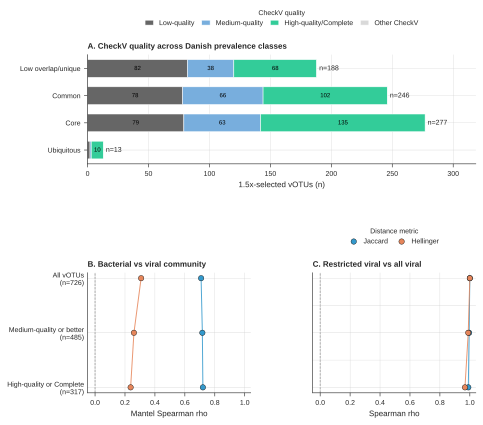

In [9]:
multiplot_path = OUTPUT_DIR / "15_quality_robustness_multiplot.svg"

with sns.axes_style("ticks", {"axes.grid": True}), plt.rc_context(
    {
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "grid.linewidth": 0.3,
        "font.family": "sans-serif",
        "font.sans-serif": ["Liberation Sans"],
        "font.size": 7,
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "axes.titleweight": "bold",
        "svg.fonttype": "none",
    }
):
    fig = plt.figure(figsize=(7.4, 6.1))
    grid = fig.add_gridspec(
        nrows=2,
        ncols=2,
        height_ratios=[1.0, 1.1],
        hspace=0.95,
        wspace=0.38,
    )
    quality_axis = fig.add_subplot(grid[0, :])
    community_axes = [
        fig.add_subplot(grid[1, 0]),
        fig.add_subplot(grid[1, 1]),
    ]

    left = np.zeros(len(quality_composition))
    quality_handles = []
    for quality_group in QUALITY_CLASS_ORDER:
        values = quality_composition[quality_group].to_numpy()
        bars = quality_axis.barh(
            quality_composition.index,
            values,
            left=left,
            color=QUALITY_CLASS_COLORS[quality_group],
            edgecolor="white",
            linewidth=0.5,
            height=0.65,
            label=quality_group,
        )
        quality_handles.append(bars[0])
        for bar, value, start in zip(bars, values, left):
            if value >= 4:
                quality_axis.text(
                    start + value / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{int(value)}",
                    ha="center",
                    va="center",
                    fontsize=6,
                    color="black",
                )
        left += values

    for y_position, total in enumerate(quality_composition.sum(axis=1)):
        quality_axis.text(
            total + max(1.5, quality_composition.to_numpy().max() * 0.015),
            y_position,
            f"n={int(total)}",
            va="center",
            fontsize=7,
        )

    quality_axis.set_title(
        "A. CheckV quality across Danish prevalence classes",
        loc="left",
    )
    quality_axis.set_xlabel("1.5x-selected vOTUs (n)")
    quality_axis.set_ylabel("")
    quality_axis.set_xlim(0, quality_composition.sum(axis=1).max() * 1.15)
    quality_axis.spines[["top", "right"]].set_visible(False)
    quality_axis.legend(
        quality_handles,
        QUALITY_CLASS_ORDER,
        title="CheckV quality",
        frameon=False,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.20),
        ncol=4,
        columnspacing=1.05,
        handlelength=1.2,
    )

    community_plot_columns = [
        (
            community_axes[0],
            "bacterial_viral_mantel_rho",
            "B. Bacterial vs viral community",
            "Mantel Spearman rho",
        ),
        (
            community_axes[1],
            "viral_distance_similarity_to_all_rho",
            "C. Restricted viral vs all viral",
            "Spearman rho",
        ),
    ]
    metric_handles = []

    for axis, value_column, title, xlabel in community_plot_columns:
        for metric, metric_label, metric_color in COMMUNITY_METRICS:
            metric_rows = (
                community_concordance_summary.loc[
                    community_concordance_summary["metric"].eq(metric)
                ]
                .set_index("quality_set")
                .reindex(QUALITY_SET_ORDER)
            )
            values = metric_rows[value_column].to_numpy()
            axis.plot(
                values,
                quality_y_positions,
                color=metric_color,
                linewidth=1.0,
                alpha=0.85,
                zorder=2,
            )
            handle = axis.scatter(
                values,
                quality_y_positions,
                color=metric_color,
                edgecolor="black",
                linewidth=0.4,
                s=30,
                zorder=3,
                label=metric_label,
            )
            if axis is community_axes[0]:
                metric_handles.append(handle)

        axis.axvline(
            0,
            color="#777777",
            linestyle="--",
            linewidth=0.65,
            zorder=0,
        )
        axis.set_title(title, loc="left")
        axis.set_xlabel(xlabel)
        axis.set_xlim(-0.05, 1.04)
        axis.spines[["top", "right"]].set_visible(False)
        axis.tick_params(axis="y", length=0)

    community_axes[0].set_yticks(quality_y_positions)
    community_axes[0].set_yticklabels(
        [quality_plot_labels[quality_set] for quality_set in QUALITY_SET_ORDER]
    )
    community_axes[1].tick_params(axis="y", labelleft=False)
    community_axes[1].legend(
        metric_handles,
        [label for _, label, _ in COMMUNITY_METRICS],
        title="Distance metric",
        frameon=False,
        ncol=2,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.18),
        columnspacing=1.35,
        handlelength=1.2,
    )

    fig.subplots_adjust(
        left=0.25,
        right=0.98,
        bottom=0.10,
        top=0.87,
        hspace=0.95,
        wspace=0.38,
    )
    fig.savefig(multiplot_path, format="svg", bbox_inches="tight")

display(SVG(filename=str(multiplot_path)))
plt.close(fig)